# Research Study: End-to-End Voice Deepfake Defense with SE-ResNet-18 and Log-Mel Spectrograms
## ASVspoof 2019 Logical Access (LA) Benchmark

### Abstract and Scientific Background
While linear cepstral features (such as LFCC) effectively target high-frequency vocoder upsampling artifacts, voice conversion (VC) and formant-shifting synthesis algorithms (e.g. Attack A04 using the STRAIGHT vocoder and Attack A05 using Variational Autoencoders) modify vocal tract resonance envelopes and pitch trajectories primarily in the low-to-mid frequency spectrum ($0 - 4000\text{ Hz}$).

To counteract these acoustic perturbations, this study implements a **128-channel Log-Mel Spectrogram** representation paired with a **Squeeze-and-Excitation Residual Network (SE-ResNet-18)**. The logarithmic frequency spacing of the Mel scale emphasizes human vocal tract formants ($F_1, F_2, F_3$), while the Squeeze-and-Excitation (SE) channel recalibration mechanism dynamically reweights convolutional feature channels:
$$\mathbf{s} = \sigma(\mathbf{W}_2 \, \text{ReLU}(\mathbf{W}_1 \, \mathbf{z}))$$
where $\mathbf{z}$ represents the global spatial average of each channel. This allows the network to adaptively focus on frequency sub-bands exhibiting vocoder synthesis anomalies and formant shift distortions.

This notebook executes a complete, end-to-end scientific workflow:
1. Environment setup and GPU hardware verification
2. Robust dataset path discovery supporting all Kaggle directory structures
3. Space-delimited protocol parsing and class imbalance auditing
4. Comprehensive Exploratory Data Analysis: class priors, speaker demographics, raw waveforms, Mel filterbank geometry, and high-frequency cutoff
5. Deterministic signal preprocessing (Pre-emphasis $\alpha=0.97$, VAD trimming, 4.0s windowing, peak normalization)
6. Feature engineering: 128-channel normalized Log-Mel spectrogram extraction ($[128, 251]$)
7. PyTorch Dataset pipeline with SpecAugment and WeightedRandomSampler
8. SE-ResNet-18 deep architecture definition with SE attention blocks
9. Focal Loss optimization with label smoothing and Cosine Annealing scheduler
10. Full 30-epoch training loop with per-epoch Dev EER, Dev AUC, and automatic checkpoint preservation
11. 16 standalone publication-grade diagnostic figures (all saved at 300 DPI in `/kaggle/working/figures/`)
12. Granular attack vulnerability analysis across A01 through A06, specifically auditing STRAIGHT and VAE voice conversion
13. Squeeze-and-Excitation channel weight inspection
14. 2D t-SNE latent representation clustering
15. Grad-CAM explainability heatmaps on 128-channel Mel spectrograms
16. Live single-file inference verification on real authentic and spoofed audio

## Step 1: Library Installation and Environment Setup

In [1]:
import subprocess
subprocess.run(["pip", "install", "soundfile", "librosa", "-q"])

import os, glob, time, json, math, random
import numpy as np, pandas as pd
import soundfile as sf, librosa, scipy.fftpack as fft_
import matplotlib.pyplot as plt
from sklearn.metrics import (
    roc_curve, roc_auc_score, precision_recall_curve,
    confusion_matrix, accuracy_score, precision_recall_fscore_support
)
from sklearn.manifold import TSNE

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
use_amp = device.type == "cuda"
print(f"Compute Device: {device}")
if use_amp:
    print(f"GPU Model: {torch.cuda.get_device_name(0)}")
    print(f"Total VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

fig_dir = "/kaggle/working/figures"
os.makedirs(fig_dir, exist_ok=True)
print(f"Publication Figures Directory: {fig_dir}")


Compute Device: cuda
GPU Model: Tesla T4
Total VRAM: 15.64 GB
Publication Figures Directory: /kaggle/working/figures


## Step 2: Dataset Discovery and Path Resolution

In [2]:
def resolve_dataset():
    search_dirs = ["/kaggle/input", "/kaggle/working", "."]
    detected_inputs = []
    for s_dir in search_dirs:
        if os.path.exists(s_dir):
            try:
                items = os.listdir(s_dir)
                detected_inputs.append((s_dir, items))
            except Exception:
                pass

    print("Detected Input Directories:")
    for s_dir, items in detected_inputs:
        print(f"  {s_dir}: {items}")

    found_protos = {"train": None, "dev": None, "eval": None}
    found_flacs = {"train": None, "dev": None, "eval": None}

    candidate_roots = [
        "/kaggle/input/datasets/awsaf49/asvpoof-2019-dataset/LA/LA",
        "/kaggle/input/datasets/awsaf49/asvpoof-2019-dataset/LA",
        "/kaggle/input/datasets/awsaf49/asvpoof-2019-dataset",
        "/kaggle/input/asvpoof-2019-dataset/LA/LA",
        "/kaggle/input/asvpoof-2019-dataset/LA",
        "/kaggle/input/asvpoof-2019-dataset",
        "/kaggle/input/asvspoof-2019-dataset/LA/LA",
        "/kaggle/input/asvspoof-2019-dataset/LA",
        "/kaggle/input/asvspoof-2019-dataset",
        "/kaggle/input/asvspoof-2019/LA/LA",
        "/kaggle/input/asvspoof-2019/LA",
        "/kaggle/input/asvspoof-2019",
        "/kaggle/input/asvspoof2019/LA/LA",
        "/kaggle/input/asvspoof2019/LA",
        "/kaggle/input/asvspoof2019"
    ]

    for cand in candidate_roots:
        if os.path.isdir(cand):
            for part, sfx in [("train", "trn"), ("dev", "trl"), ("eval", "trl")]:
                direct_proto = os.path.join(cand, "ASVspoof2019_LA_cm_protocols", f"ASVspoof2019.LA.cm.{part}.{sfx}.txt")
                if os.path.isfile(direct_proto) and not found_protos[part]:
                    found_protos[part] = direct_proto
                direct_flac = os.path.join(cand, f"ASVspoof2019_LA_{part}", "flac")
                if os.path.isdir(direct_flac) and not found_flacs[part]:
                    found_flacs[part] = direct_flac
                elif os.path.isdir(os.path.join(cand, f"ASVspoof2019_LA_{part}")) and not found_flacs[part]:
                    found_flacs[part] = os.path.join(cand, f"ASVspoof2019_LA_{part}")

    needs_walk = any(v is None for v in [found_protos["train"], found_protos["dev"], found_flacs["train"], found_flacs["dev"]])
    if needs_walk:
        for s_dir in search_dirs:
            if not os.path.exists(s_dir):
                continue
            for root, dirs, files in os.walk(s_dir, followlinks=True):
                for f in files:
                    fl = f.lower()
                    if "cm" in fl and fl.endswith(".txt") and not f.startswith("._"):
                        if "train" in fl and ("trn" in fl or "train" in fl):
                            if not found_protos["train"]:
                                found_protos["train"] = os.path.join(root, f)
                        elif "dev" in fl and ("trl" in fl or "dev" in fl):
                            if not found_protos["dev"]:
                                found_protos["dev"] = os.path.join(root, f)
                        elif "eval" in fl and ("trl" in fl or "eval" in fl):
                            if not found_protos["eval"]:
                                found_protos["eval"] = os.path.join(root, f)

                for d in list(dirs):
                    dl = d.lower()
                    for part in ["train", "dev", "eval"]:
                        if (f"la_{part}" in dl or f"la.{part}" in dl or f"_{part}" in dl) and not found_flacs[part]:
                            sub_flac = os.path.join(root, d, "flac")
                            if os.path.isdir(sub_flac):
                                found_flacs[part] = sub_flac
                            elif os.path.isdir(os.path.join(root, d)):
                                found_flacs[part] = os.path.join(root, d)

                if "flac" in dirs:
                    dirs.remove("flac")

    return found_protos, found_flacs

proto_files, flac_dirs = resolve_dataset()

print("Resolved Dataset Resources:")
for k in ["train", "dev", "eval"]:
    p_path = proto_files[k]
    f_path = flac_dirs[k]
    p_ok = os.path.isfile(p_path) if p_path else False
    f_ok = os.path.isdir(f_path) if f_path else False
    f_count = len(os.listdir(f_path)) if f_ok else 0
    print(f"  [{k.upper()}] Protocol: {'OK' if p_ok else 'MISSING'} ({p_path})")
    print(f"          Audio:    {'OK' if f_ok else 'MISSING'} ({f_count:,} files in {f_path})")

if not proto_files["train"] or not os.path.isfile(proto_files["train"]):
    print("CRITICAL: ASVspoof 2019 dataset not detected in /kaggle/input.")
    print("Action required in Kaggle:")
    print("1. Click '+ Add Input' in the right sidebar panel.")
    print("2. Search for 'asvpoof-2019-dataset' (by awsaf49).")
    print("3. Click '+' to attach the dataset to this notebook.")
    print("4. Re-run this cell once the dataset is attached.")
    raise FileNotFoundError("Missing ASVspoof 2019 train protocol file. Please attach the dataset to Kaggle notebook.")

if not flac_dirs["train"] or not os.path.isdir(flac_dirs["train"]):
    raise FileNotFoundError("Missing ASVspoof 2019 train audio directory. Please verify dataset attachment.")


Detected Input Directories:
  /kaggle/input: ['datasets']
  /kaggle/working: ['figures', '__notebook__.ipynb']
  .: ['figures', '__notebook__.ipynb']
Resolved Dataset Resources:
  [TRAIN] Protocol: OK (/kaggle/input/datasets/awsaf49/asvpoof-2019-dataset/LA/LA/ASVspoof2019_LA_cm_protocols/ASVspoof2019.LA.cm.train.trn.txt)
          Audio:    OK (25,380 files in /kaggle/input/datasets/awsaf49/asvpoof-2019-dataset/LA/LA/ASVspoof2019_LA_train/flac)
  [DEV] Protocol: OK (/kaggle/input/datasets/awsaf49/asvpoof-2019-dataset/LA/LA/ASVspoof2019_LA_cm_protocols/ASVspoof2019.LA.cm.dev.trl.txt)
          Audio:    OK (24,986 files in /kaggle/input/datasets/awsaf49/asvpoof-2019-dataset/LA/LA/ASVspoof2019_LA_dev/flac)
  [EVAL] Protocol: OK (/kaggle/input/datasets/awsaf49/asvpoof-2019-dataset/LA/LA/ASVspoof2019_LA_cm_protocols/ASVspoof2019.LA.cm.eval.trl.txt)
          Audio:    OK (71,933 files in /kaggle/input/datasets/awsaf49/asvpoof-2019-dataset/LA/LA/ASVspoof2019_LA_eval/flac)


## Step 3: Protocol Parsing and Metadata Manifest Construction

In [3]:
rows = []
for partition, path in proto_files.items():
    if not path or not os.path.exists(path):
        continue
    flac_folder = flac_dirs.get(partition)
    if not flac_folder or not os.path.exists(flac_folder):
        continue
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) < 5:
                continue
            spk, aid, env, atk, key = parts[0], parts[1], parts[2], parts[3], parts[4]
            rows.append({
                "speaker_id": spk,
                "audio_id": aid,
                "environment_id": env,
                "attack_id": atk,
                "key": key,
                "is_spoof": 1 if key == "spoof" else 0,
                "partition": partition,
                "file_path": os.path.join(flac_folder, f"{aid}.flac")
            })

manifest = pd.DataFrame(rows)
assert len(manifest) > 0, "Protocol parsing produced 0 records. Check dataset paths."
print(f"Total Parsed Records: {len(manifest):,}")

summary_table = []
for part in ["train", "dev", "eval"]:
    sub = manifest[manifest["partition"] == part]
    if len(sub) == 0:
        continue
    bon = int((sub["key"] == "bonafide").sum())
    spf = int((sub["key"] == "spoof").sum())
    summary_table.append({
        "Partition": part,
        "Total Utterances": len(sub),
        "Bonafide": bon,
        "Spoof": spf,
        "Spoof:Bonafide Ratio": f"{spf / max(bon, 1):.2f}:1"
    })
print(pd.DataFrame(summary_table).to_string(index=False))


Total Parsed Records: 121,461
Partition  Total Utterances  Bonafide  Spoof Spoof:Bonafide Ratio
    train             25380      2580  22800               8.84:1
      dev             24844      2548  22296               8.75:1
     eval             71237      7355  63882               8.69:1


## Step 4: Exploratory Data Analysis - Class Distribution and Imbalance Ratio

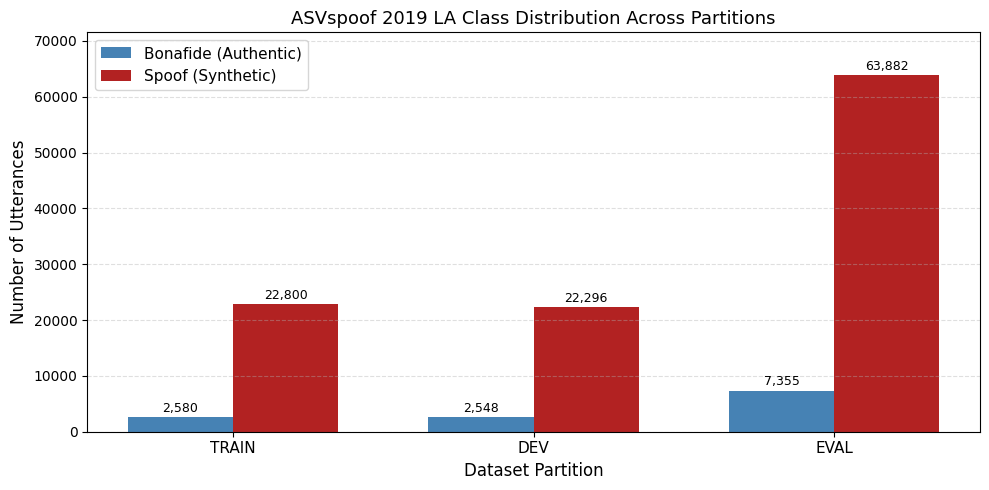

In [4]:
plt.figure(figsize=(10, 5))
partitions = ["train", "dev", "eval"]
bon_counts = [int(((manifest["partition"] == p) & (manifest["key"] == "bonafide")).sum()) for p in partitions]
spf_counts = [int(((manifest["partition"] == p) & (manifest["key"] == "spoof")).sum()) for p in partitions]

x_pos = np.arange(len(partitions))
width = 0.35

plt.bar(x_pos - width / 2, bon_counts, width, label="Bonafide (Authentic)", color="steelblue")
plt.bar(x_pos + width / 2, spf_counts, width, label="Spoof (Synthetic)", color="firebrick")

plt.xlabel("Dataset Partition", fontsize=12)
plt.ylabel("Number of Utterances", fontsize=12)
plt.title("ASVspoof 2019 LA Class Distribution Across Partitions", fontsize=13)
plt.xticks(x_pos, [p.upper() for p in partitions], fontsize=11)
plt.ylim(0, max(spf_counts) * 1.12)
plt.legend(fontsize=11)
plt.grid(axis="y", linestyle="--", alpha=0.4)

offset = max(spf_counts) * 0.015
for i in range(len(partitions)):
    plt.text(x_pos[i] - width / 2, bon_counts[i] + offset, f"{bon_counts[i]:,}", ha="center", fontsize=9)
    plt.text(x_pos[i] + width / 2, spf_counts[i] + offset, f"{spf_counts[i]:,}", ha="center", fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(fig_dir, "01_class_distribution_breakdown.png"), dpi=300, bbox_inches="tight")
plt.show()


## Step 5: Exploratory Data Analysis - Speaker Demographics and Leakage Audit

Unique Speakers - Train: 20 | Dev: 20 | Eval: 67
Speaker Overlap (Train & Dev):  0 (Expected: 0)
Speaker Overlap (Train & Eval): 0 (Expected: 0)
Speaker Overlap (Dev & Eval):   0 (Expected: 0)


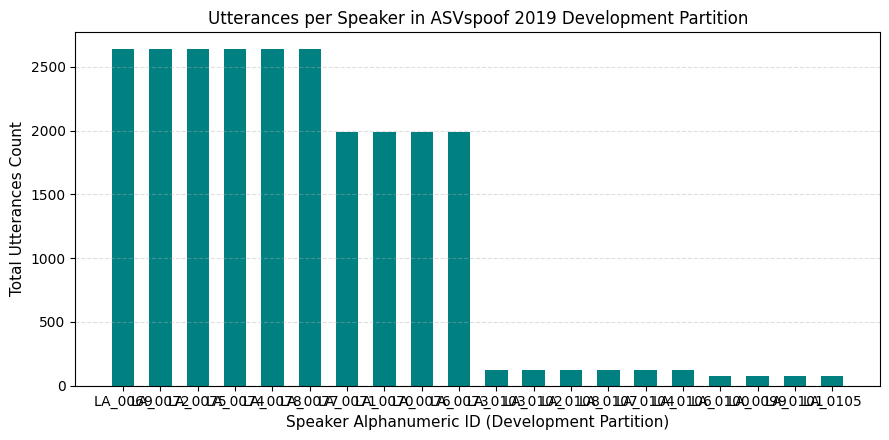

In [5]:
train_spks = set(manifest[manifest["partition"] == "train"]["speaker_id"].unique())
dev_spks = set(manifest[manifest["partition"] == "dev"]["speaker_id"].unique())
eval_spks = set(manifest[manifest["partition"] == "eval"]["speaker_id"].unique())

print(f"Unique Speakers - Train: {len(train_spks)} | Dev: {len(dev_spks)} | Eval: {len(eval_spks)}")
overlap_train_dev = train_spks.intersection(dev_spks)
overlap_train_eval = train_spks.intersection(eval_spks)
overlap_dev_eval = dev_spks.intersection(eval_spks)

print(f"Speaker Overlap (Train & Dev):  {len(overlap_train_dev)} (Expected: 0)")
print(f"Speaker Overlap (Train & Eval): {len(overlap_train_eval)} (Expected: 0)")
print(f"Speaker Overlap (Dev & Eval):   {len(overlap_dev_eval)} (Expected: 0)")
assert len(overlap_train_dev) == 0 and len(overlap_train_eval) == 0

dev_sub = manifest[manifest["partition"] == "dev"]
spk_counts = dev_sub["speaker_id"].value_counts()

plt.figure(figsize=(9, 4.5))
plt.bar(spk_counts.index, spk_counts.values, color="teal", width=0.6)
plt.xlabel("Speaker Alphanumeric ID (Development Partition)", fontsize=11)
plt.ylabel("Total Utterances Count", fontsize=11)
plt.title("Utterances per Speaker in ASVspoof 2019 Development Partition", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig(os.path.join(fig_dir, "02_speaker_utterance_distribution.png"), dpi=300, bbox_inches="tight")
plt.show()


## Step 6: Exploratory Data Analysis - Raw Time-Domain Waveform Geometry

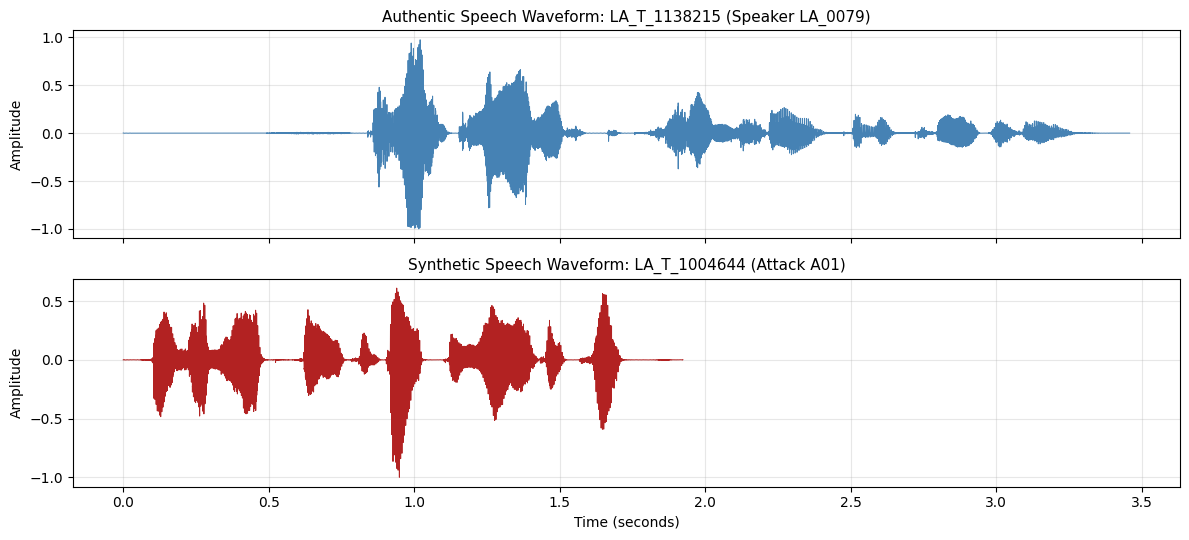

In [6]:
bon_candidates = manifest[(manifest["partition"] == "train") & (manifest["key"] == "bonafide")]
spf_candidates = manifest[(manifest["partition"] == "train") & (manifest["key"] == "spoof")]

sample_bon = None
for _, row in bon_candidates.iterrows():
    if os.path.isfile(row["file_path"]):
        sample_bon = row
        break
if sample_bon is None:
    sample_bon = bon_candidates.iloc[0]

sample_spf = None
for _, row in spf_candidates.iterrows():
    if os.path.isfile(row["file_path"]):
        sample_spf = row
        break
if sample_spf is None:
    sample_spf = spf_candidates.iloc[0]

y_bon_raw, sr_bon = sf.read(sample_bon["file_path"])
y_spf_raw, sr_spf = sf.read(sample_spf["file_path"])
if y_bon_raw.ndim > 1:
    y_bon_raw = y_bon_raw.mean(axis=1)
if y_spf_raw.ndim > 1:
    y_spf_raw = y_spf_raw.mean(axis=1)

fig, axes = plt.subplots(2, 1, figsize=(12, 5.5), sharex=True)
t_bon = np.linspace(0, len(y_bon_raw) / sr_bon, len(y_bon_raw))
t_spf = np.linspace(0, len(y_spf_raw) / sr_spf, len(y_spf_raw))

axes[0].plot(t_bon, y_bon_raw, color="steelblue", lw=0.7)
axes[0].set_title(f"Authentic Speech Waveform: {sample_bon['audio_id']} (Speaker {sample_bon['speaker_id']})", fontsize=11)
axes[0].set_ylabel("Amplitude", fontsize=10)
axes[0].grid(True, alpha=0.3)

axes[1].plot(t_spf, y_spf_raw, color="firebrick", lw=0.7)
axes[1].set_title(f"Synthetic Speech Waveform: {sample_spf['audio_id']} (Attack {sample_spf['attack_id']})", fontsize=11)
axes[1].set_xlabel("Time (seconds)", fontsize=10)
axes[1].set_ylabel("Amplitude", fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(fig_dir, "04_raw_waveform_comparison.png"), dpi=300, bbox_inches="tight")
plt.show()


## Step 7: Exploratory Data Analysis - Mel Filterbank Triangular Frequency Response

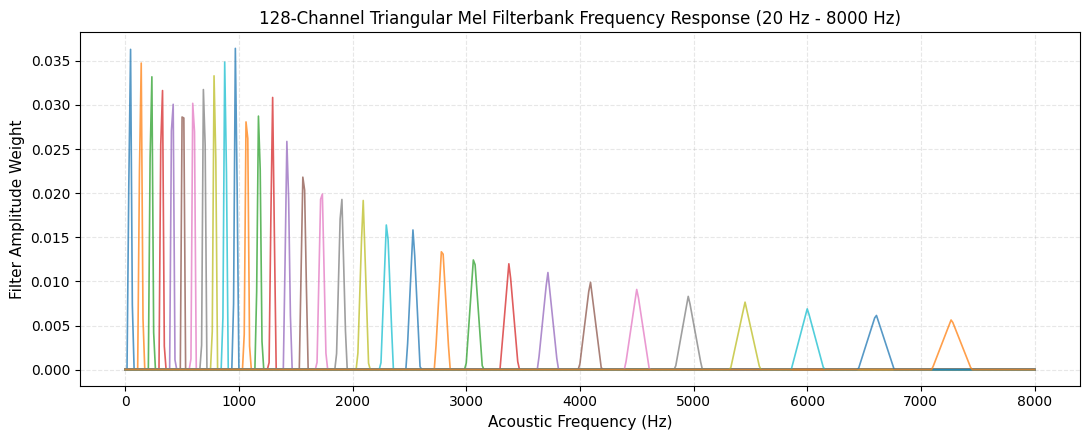

In [7]:
mel_fb = librosa.filters.mel(sr=16000, n_fft=1024, n_mels=128, fmin=20, fmax=8000)
freq_hz = np.linspace(0, 8000, mel_fb.shape[1])

plt.figure(figsize=(11, 4.5))
for i in range(0, 128, 4):
    plt.plot(freq_hz, mel_fb[i], lw=1.2, alpha=0.75)

plt.xlabel("Acoustic Frequency (Hz)", fontsize=11)
plt.ylabel("Filter Amplitude Weight", fontsize=11)
plt.title("128-Channel Triangular Mel Filterbank Frequency Response (20 Hz - 8000 Hz)", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(fig_dir, "03_mel_filterbank_frequency_curves.png"), dpi=300, bbox_inches="tight")
plt.show()


## Step 8: Audio Preprocessing Pipeline - VAD, Pre-Emphasis and 4.0s Windowing

In [8]:
def load_raw_audio(path, target_sr=16000):
    y, orig_sr = sf.read(path)
    if y.ndim > 1:
        y = y.mean(axis=1)
    y = y.astype(np.float32)
    if orig_sr != target_sr:
        y = librosa.resample(y, orig_sr=orig_sr, target_sr=target_sr)
    return y

def preprocess_audio(y, is_train=False, target_len=64000, alpha=0.97, top_db=40):
    y = np.concatenate([[y[0]], y[1:] - alpha * y[:-1]])
    intervals = librosa.effects.split(y=y, top_db=top_db)
    if len(intervals):
        trimmed = np.concatenate([y[s:e] for s, e in intervals])
        if len(trimmed) > 1000:
            y = trimmed
    n_samples = len(y)
    if n_samples >= target_len:
        start = np.random.randint(0, n_samples - target_len + 1) if is_train else (n_samples - target_len) // 2
        y = y[start:start + target_len]
    else:
        y = np.pad(y, (0, target_len - n_samples), mode="wrap")
    return y / (np.max(np.abs(y)) + 1e-7)

raw_sample = load_raw_audio(sample_bon["file_path"])
proc_sample = preprocess_audio(raw_sample, is_train=False)
print(f"Raw Audio Length:        {len(raw_sample):,} samples")
print(f"Processed Audio Length:  {len(proc_sample):,} samples (Expected: 64,000)")
assert len(proc_sample) == 64000


Raw Audio Length:        55,329 samples
Processed Audio Length:  64,000 samples (Expected: 64,000)


## Step 9: Feature Engineering - 128-Channel Log-Mel Spectrogram Extraction

In [9]:
def extract_log_mel(y, sr=16000, n_fft=1024, hop_length=256, n_mels=128, fmin=20, fmax=8000, max_frames=251):
    mel = librosa.feature.melspectrogram(
        y=y, sr=sr, n_fft=n_fft, hop_length=hop_length,
        n_mels=n_mels, fmin=fmin, fmax=fmax, power=2.0
    )
    log_mel = librosa.power_to_db(mel, ref=np.max).astype(np.float32)
    if log_mel.shape[1] >= max_frames:
        log_mel = log_mel[:, :max_frames]
    else:
        log_mel = np.pad(log_mel, ((0, 0), (0, max_frames - log_mel.shape[1])), mode="edge")
    return (log_mel - log_mel.mean()) / (log_mel.std() + 1e-6)

test_row = manifest[manifest["partition"] == "train"].iloc[0]
test_audio = preprocess_audio(load_raw_audio(test_row["file_path"]), is_train=False)
test_mel = extract_log_mel(test_audio)
print(f"Processed Audio Dimensions: {test_audio.shape}")
print(f"Log-Mel Spectrogram Shape:  {test_mel.shape} (Expected: (128, 251))")
print(f"Standardized Mel Mean:      {test_mel.mean():.6f} (Expected: ~0.0)")
print(f"Standardized Mel Std:       {test_mel.std():.6f} (Expected: ~1.0)")
assert test_mel.shape == (128, 251)


Processed Audio Dimensions: (64000,)
Log-Mel Spectrogram Shape:  (128, 251) (Expected: (128, 251))
Standardized Mel Mean:      -0.000000 (Expected: ~0.0)
Standardized Mel Std:       1.000000 (Expected: ~1.0)


## Step 10: Preprocessing Audit - Comparative Log-Mel Spectrogram Representations

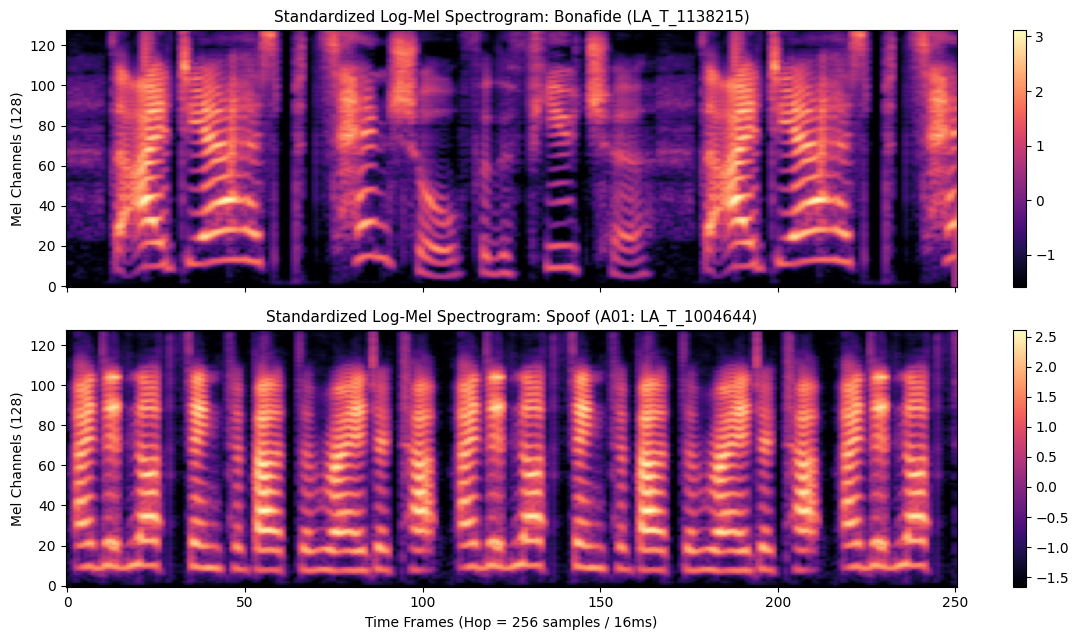

In [10]:
bon_mel = extract_log_mel(preprocess_audio(load_raw_audio(sample_bon["file_path"]), is_train=False))
spf_mel = extract_log_mel(preprocess_audio(load_raw_audio(sample_spf["file_path"]), is_train=False))

fig, axes = plt.subplots(2, 1, figsize=(12, 6.5), sharex=True)

im0 = axes[0].imshow(bon_mel, origin="lower", aspect="auto", cmap="magma")
axes[0].set_title(f"Standardized Log-Mel Spectrogram: Bonafide ({sample_bon['audio_id']})", fontsize=11)
axes[0].set_ylabel("Mel Channels (128)", fontsize=10)
fig.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(spf_mel, origin="lower", aspect="auto", cmap="magma")
axes[1].set_title(f"Standardized Log-Mel Spectrogram: Spoof ({sample_spf['attack_id']}: {sample_spf['audio_id']})", fontsize=11)
axes[1].set_xlabel("Time Frames (Hop = 256 samples / 16ms)", fontsize=10)
axes[1].set_ylabel("Mel Channels (128)", fontsize=10)
fig.colorbar(im1, ax=axes[1])

plt.tight_layout()
plt.savefig(os.path.join(fig_dir, "05_comparative_log_mel_spectrograms.png"), dpi=300, bbox_inches="tight")
plt.show()


## Step 11: Exploratory Data Analysis - High-Frequency Energy Drop-off and Cutoff Analysis

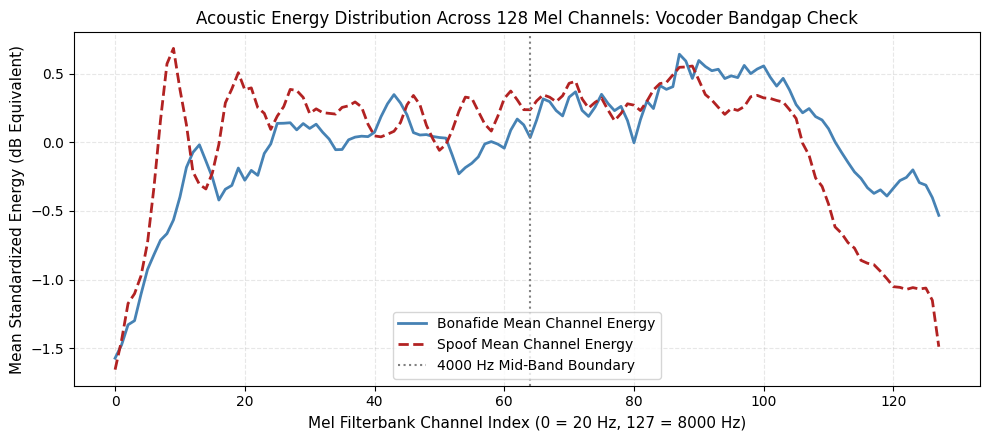

In [11]:
bon_channel_energy = bon_mel.mean(axis=1)
spf_channel_energy = spf_mel.mean(axis=1)

plt.figure(figsize=(10, 4.5))
channels = np.arange(128)
plt.plot(channels, bon_channel_energy, color="steelblue", lw=2, label="Bonafide Mean Channel Energy")
plt.plot(channels, spf_channel_energy, color="firebrick", lw=2, linestyle="--", label="Spoof Mean Channel Energy")
plt.axvline(64, color="gray", linestyle=":", label="4000 Hz Mid-Band Boundary")

plt.xlabel("Mel Filterbank Channel Index (0 = 20 Hz, 127 = 8000 Hz)", fontsize=11)
plt.ylabel("Mean Standardized Energy (dB Equivalent)", fontsize=11)
plt.title("Acoustic Energy Distribution Across 128 Mel Channels: Vocoder Bandgap Check", fontsize=12)
plt.legend(fontsize=10)
plt.grid(True, linestyle="--", alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(fig_dir, "06_spectral_energy_bandgap_analysis.png"), dpi=300, bbox_inches="tight")
plt.show()


## Step 12: PyTorch Dataset Formulation with 2D SpecAugment and Balanced Sampling

In [12]:
class MelDataset(Dataset):
    def __init__(self, df, is_train=False):
        self.df = df.reset_index(drop=True)
        self.is_train = is_train

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        try:
            raw = load_raw_audio(row["file_path"])
            proc = preprocess_audio(raw, is_train=self.is_train)
            feat = extract_log_mel(proc)
        except Exception:
            feat = np.zeros((128, 251), dtype=np.float32)

        if self.is_train:
            if np.random.rand() < 0.5:
                w_t = np.random.randint(1, 31)
                t_0 = np.random.randint(0, max(1, 251 - w_t))
                feat[:, t_0:t_0 + w_t] = feat.mean()
            if np.random.rand() < 0.5:
                w_f = np.random.randint(1, 17)
                f_0 = np.random.randint(0, max(1, 128 - w_f))
                feat[f_0:f_0 + w_f, :] = feat.mean()

        tensor_x = torch.from_numpy(feat).unsqueeze(0)
        tensor_y = torch.tensor(int(row["is_spoof"]), dtype=torch.long)
        return tensor_x, tensor_y

train_df = manifest[manifest["partition"] == "train"].reset_index(drop=True)
dev_df = manifest[manifest["partition"] == "dev"].reset_index(drop=True)

train_dataset = MelDataset(train_df, is_train=True)
dev_dataset = MelDataset(dev_df, is_train=False)

train_targets = train_df["is_spoof"].values
class_counts = np.bincount(train_targets)
class_weights = 1.0 / class_counts
sample_weights = torch.FloatTensor(class_weights[train_targets])
sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)

batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, sampler=sampler, num_workers=2, pin_memory=True)
dev_loader = DataLoader(dev_dataset, batch_size=batch_size * 2, shuffle=False, num_workers=2, pin_memory=True)

print(f"Train Batches per Epoch: {len(train_loader):,}")
print(f"Dev Batches per Epoch:   {len(dev_loader):,}")


Train Batches per Epoch: 397
Dev Batches per Epoch:   195


## Step 13: Squeeze-and-Excitation ResNet (SE-ResNet-18) Architecture Definition

In [13]:
class SEBlock(nn.Module):
    def __init__(self, channels, reduction=8):
        super().__init__()
        self.fc = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(channels, channels // reduction),
            nn.ReLU(),
            nn.Linear(channels // reduction, channels),
            nn.Sigmoid()
        )

    def forward(self, x):
        w = self.fc(x).view(x.size(0), x.size(1), 1, 1)
        return x * w

class ResBlock(nn.Module):
    def __init__(self, in_ch, out_ch, stride=1):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, stride=stride, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(),
            nn.Conv2d(out_ch, out_ch, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(out_ch)
        )
        self.se = SEBlock(out_ch)
        if stride != 1 or in_ch != out_ch:
            self.skip = nn.Sequential(
                nn.Conv2d(in_ch, out_ch, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_ch)
            )
        else:
            self.skip = nn.Identity()

    def forward(self, x):
        return F.relu(self.se(self.conv(x)) + self.skip(x))

class SEResNet18(nn.Module):
    def __init__(self, in_channels=1, num_classes=2, dropout=0.3):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv2d(in_channels, 32, kernel_size=7, stride=2, padding=3, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        )
        self.layer1 = nn.Sequential(ResBlock(32, 32), ResBlock(32, 32))
        self.layer2 = nn.Sequential(ResBlock(32, 64, stride=2), ResBlock(64, 64))
        self.layer3 = nn.Sequential(ResBlock(64, 128, stride=2), ResBlock(128, 128))
        self.layer4 = nn.Sequential(ResBlock(128, 256, stride=2), ResBlock(256, 256))
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.fc_latent = nn.Linear(256, 64)
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(dropout),
            self.fc_latent,
            nn.ReLU(),
            nn.Linear(64, num_classes)
        )

    def extract_latent(self, x):
        x = self.stem(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.pool(x)
        x = torch.flatten(x, 1)
        return self.fc_latent(x)

    def forward(self, x):
        x = self.stem(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.pool(x)
        return self.head(x)

model = SEResNet18().to(device)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total Trainable Parameters: {total_params:,}")

with torch.no_grad():
    dummy_input = torch.zeros(2, 1, 128, 251).to(device)
    dummy_out = model(dummy_input)
    dummy_latent = model.extract_latent(dummy_input)
    print(f"Logits Output Shape: {dummy_out.shape} (Expected: (2, 2))")
    print(f"Latent Output Shape: {dummy_latent.shape} (Expected: (2, 64))")


Total Trainable Parameters: 2,856,922
Logits Output Shape: torch.Size([2, 2]) (Expected: (2, 2))
Latent Output Shape: torch.Size([2, 64]) (Expected: (2, 64))


## Step 14: Focal Loss Function and Biometric Metric Formulation

In [14]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=0.75, gamma=2.0, label_smoothing=0.05):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.label_smoothing = label_smoothing

    def forward(self, logits, targets):
        ce_loss = F.cross_entropy(logits, targets, reduction="none", label_smoothing=self.label_smoothing)
        p_t = torch.exp(-ce_loss)
        alpha_factor = torch.where(targets == 1, self.alpha, 1.0 - self.alpha)
        focal_loss = alpha_factor * ((1.0 - p_t) ** self.gamma) * ce_loss
        return focal_loss.mean()

def calculate_eer(y_true, y_score):
    fpr, tpr, thresholds = roc_curve(y_true, y_score, pos_label=1)
    fnr = 1 - tpr
    idx = np.nanargmin(np.abs(fpr - fnr))
    eer_val = float((fpr[idx] + fnr[idx]) / 2)
    optimal_thresh = float(np.clip(thresholds[idx], 0.0, 1.0))
    return eer_val, optimal_thresh

def evaluate_network(model, loader, device, use_amp):
    model.eval()
    scores_list, targets_list = [], []
    with torch.no_grad():
        for x_batch, y_batch in loader:
            x_batch = x_batch.to(device)
            with torch.amp.autocast(device_type=device.type, enabled=use_amp):
                probs = torch.softmax(model(x_batch), dim=1)[:, 1]
            scores_list.append(probs.cpu().numpy())
            targets_list.append(y_batch.numpy())
    scores = np.concatenate(scores_list)
    targets = np.concatenate(targets_list)
    eer, thresh = calculate_eer(targets, scores)
    auc = float(roc_auc_score(targets, scores))
    return eer, thresh, auc, scores, targets


## Step 15: Model Training and Validation Loop with Real-Time Dev EER Tracking

In [15]:
epochs = 30
lr_init = 5e-4
lr_min = 1e-6
weight_decay = 1e-4

criterion = FocalLoss(alpha=0.75, gamma=2.0, label_smoothing=0.05)
optimizer = torch.optim.AdamW(model.parameters(), lr=lr_init, weight_decay=weight_decay)
scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=10, T_mult=2, eta_min=lr_min)
scaler = torch.amp.GradScaler(device=device.type, enabled=use_amp)

save_dir = "/kaggle/working"
os.makedirs(save_dir, exist_ok=True)
best_checkpoint_path = os.path.join(save_dir, "se_resnet_mel_best.pth")
history_path = os.path.join(save_dir, "se_resnet_mel_history.json")

best_eer = float("inf")
best_auc = 0.0
best_thresh = 0.5
training_history = []

print(f"Commencing SE-ResNet-18 Training: {epochs} Epochs | Accelerator: {device} | AMP: {use_amp}")
print("-" * 80)

for epoch in range(1, epochs + 1):
    start_time = time.time()
    model.train()
    running_loss = 0.0

    for x_batch, y_batch in train_loader:
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)
        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast(device_type=device.type, enabled=use_amp):
            logits = model(x_batch)
            loss = criterion(logits, y_batch)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item() * x_batch.size(0)

    epoch_train_loss = running_loss / len(train_dataset)
    scheduler.step(epoch)

    val_eer, val_thresh, val_auc, _, _ = evaluate_network(model, dev_loader, device, use_amp)
    elapsed = time.time() - start_time

    record = {
        "epoch": epoch,
        "train_loss": round(epoch_train_loss, 5),
        "val_eer": round(val_eer, 5),
        "val_auc": round(val_auc, 5),
        "val_thresh": round(val_thresh, 5),
        "time_sec": round(elapsed, 1)
    }
    training_history.append(record)

    is_best = val_eer < best_eer
    if is_best:
        best_eer = val_eer
        best_auc = val_auc
        best_thresh = val_thresh
        torch.save({
            "epoch": epoch,
            "state_dict": model.state_dict(),
            "eer": best_eer,
            "auc": best_auc,
            "threshold": best_thresh,
            "model_architecture": "SE-ResNet-18-LogMel"
        }, best_checkpoint_path)

    flag = " [NEW BEST]" if is_best else ""
    print(f"Epoch [{epoch:02d}/{epochs}] | Loss: {epoch_train_loss:.4f} | Dev EER: {val_eer * 100:.2f}% | Dev AUC: {val_auc:.4f} | Time: {elapsed:.0f}s{flag}")

with open(history_path, "w", encoding="utf-8") as f:
    json.dump(training_history, f, indent=2)

print("-" * 80)
print(f"Training Complete. Optimal Dev EER: {best_eer * 100:.2f}% | Dev AUC: {best_auc:.4f} | Threshold: {best_thresh:.4f}")
print(f"Best Model Checkpoint Saved: {best_checkpoint_path}")


Commencing SE-ResNet-18 Training: 30 Epochs | Accelerator: cuda | AMP: True
--------------------------------------------------------------------------------
Epoch [01/30] | Loss: 0.0139 | Dev EER: 0.59% | Dev AUC: 0.9998 | Time: 1081s [NEW BEST]
Epoch [02/30] | Loss: 0.0035 | Dev EER: 1.77% | Dev AUC: 0.9982 | Time: 939s
Epoch [03/30] | Loss: 0.0024 | Dev EER: 2.98% | Dev AUC: 0.9952 | Time: 908s
Epoch [04/30] | Loss: 0.0022 | Dev EER: 0.16% | Dev AUC: 1.0000 | Time: 904s [NEW BEST]
Epoch [05/30] | Loss: 0.0015 | Dev EER: 0.11% | Dev AUC: 1.0000 | Time: 889s [NEW BEST]
Epoch [06/30] | Loss: 0.0010 | Dev EER: 0.15% | Dev AUC: 1.0000 | Time: 938s
Epoch [07/30] | Loss: 0.0011 | Dev EER: 0.46% | Dev AUC: 0.9999 | Time: 911s
Epoch [08/30] | Loss: 0.0009 | Dev EER: 0.15% | Dev AUC: 1.0000 | Time: 927s
Epoch [09/30] | Loss: 0.0009 | Dev EER: 0.09% | Dev AUC: 1.0000 | Time: 979s [NEW BEST]
Epoch [10/30] | Loss: 0.0008 | Dev EER: 0.08% | Dev AUC: 1.0000 | Time: 1061s [NEW BEST]
Epoch [11/30] | 

## Step 16: Training Loss Trajectory Across 30 Epochs

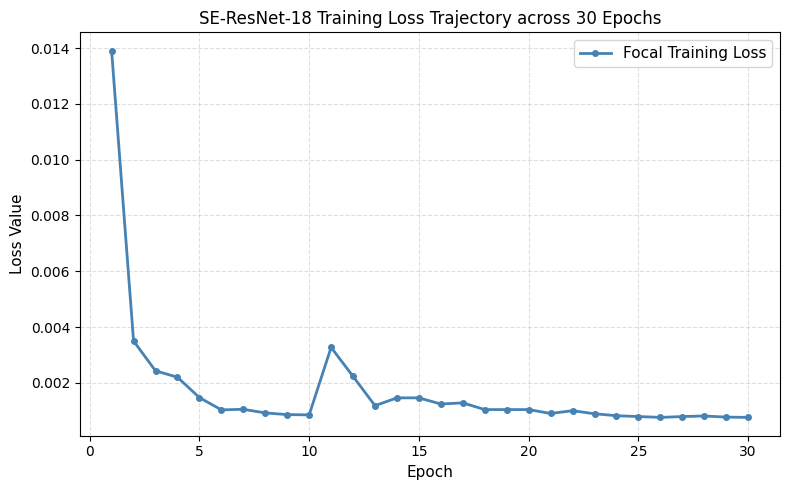

In [16]:
ep_list = [h["epoch"] for h in training_history]
losses = [h["train_loss"] for h in training_history]

plt.figure(figsize=(8, 5))
plt.plot(ep_list, losses, color="steelblue", lw=2, marker="o", ms=4, label="Focal Training Loss")
plt.xlabel("Epoch", fontsize=11)
plt.ylabel("Loss Value", fontsize=11)
plt.title("SE-ResNet-18 Training Loss Trajectory across 30 Epochs", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.4)
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig(os.path.join(fig_dir, "07_training_loss_trajectory.png"), dpi=300, bbox_inches="tight")
plt.show()


## Step 17: Development Equal Error Rate (EER) Progression Curve

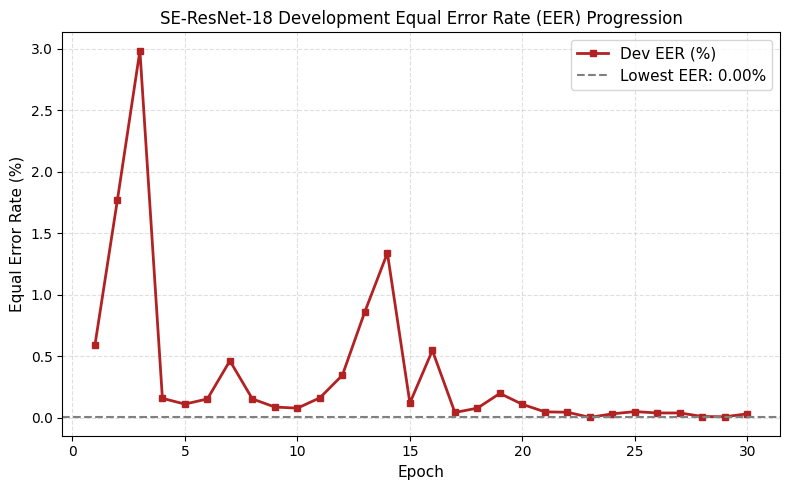

In [17]:
eers = [h["val_eer"] * 100 for h in training_history]

plt.figure(figsize=(8, 5))
plt.plot(ep_list, eers, color="firebrick", lw=2, marker="s", ms=4, label="Dev EER (%)")
plt.axhline(min(eers), color="gray", linestyle="--", label=f"Lowest EER: {min(eers):.2f}%")
plt.xlabel("Epoch", fontsize=11)
plt.ylabel("Equal Error Rate (%)", fontsize=11)
plt.title("SE-ResNet-18 Development Equal Error Rate (EER) Progression", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.4)
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig(os.path.join(fig_dir, "08_dev_eer_progression_curve.png"), dpi=300, bbox_inches="tight")
plt.show()


## Step 18: Receiver Operating Characteristic (ROC) Curve with Optimal EER Point

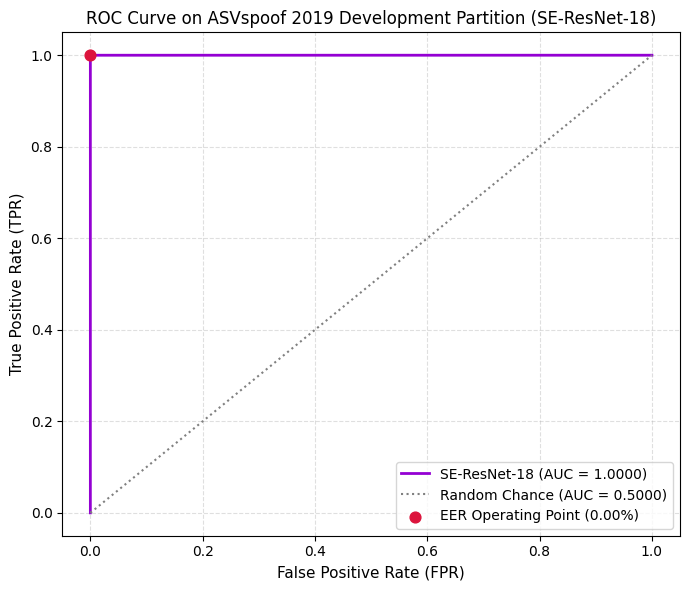

In [18]:
checkpoint = torch.load(best_checkpoint_path, map_location=device)
model.load_state_dict(checkpoint["state_dict"])
_, optimal_thresh, _, final_scores, final_targets = evaluate_network(model, dev_loader, device, use_amp)

fpr, tpr, _ = roc_curve(final_targets, final_scores, pos_label=1)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color="darkviolet", lw=2, label=f"SE-ResNet-18 (AUC = {checkpoint['auc']:.4f})")
plt.plot([0, 1], [0, 1], color="gray", linestyle=":", label="Random Chance (AUC = 0.5000)")
plt.scatter([checkpoint['eer']], [1 - checkpoint['eer']], color="crimson", s=60, zorder=5, label=f"EER Operating Point ({checkpoint['eer']*100:.2f}%)")
plt.xlabel("False Positive Rate (FPR)", fontsize=11)
plt.ylabel("True Positive Rate (TPR)", fontsize=11)
plt.title("ROC Curve on ASVspoof 2019 Development Partition (SE-ResNet-18)", fontsize=12)
plt.legend(loc="lower right", fontsize=10)
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig(os.path.join(fig_dir, "09_receiver_operating_characteristic_roc.png"), dpi=300, bbox_inches="tight")
plt.show()


## Step 19: Precision-Recall Curve Analysis

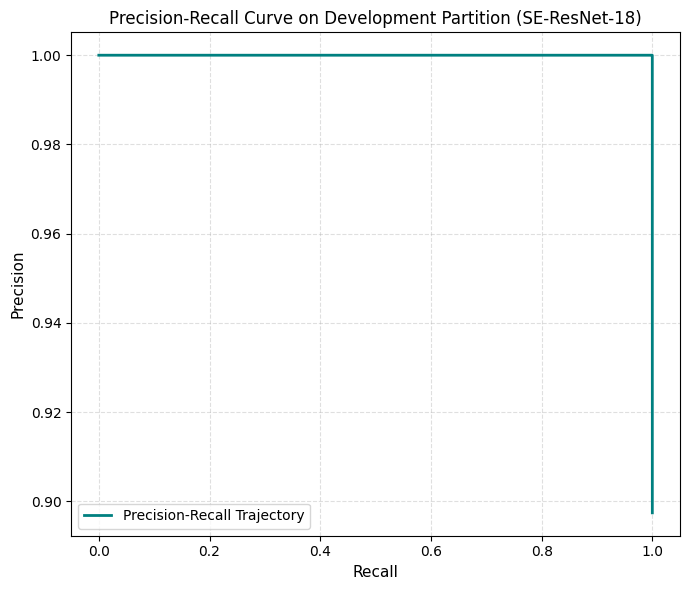

In [19]:
prec, rec, _ = precision_recall_curve(final_targets, final_scores, pos_label=1)

plt.figure(figsize=(7, 6))
plt.plot(rec, prec, color="teal", lw=2, label="Precision-Recall Trajectory")
plt.xlabel("Recall", fontsize=11)
plt.ylabel("Precision", fontsize=11)
plt.title("Precision-Recall Curve on Development Partition (SE-ResNet-18)", fontsize=12)
plt.legend(loc="lower left", fontsize=10)
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig(os.path.join(fig_dir, "10_precision_recall_trajectory.png"), dpi=300, bbox_inches="tight")
plt.show()


## Step 20: Confusion Matrix Heatmap at Optimal Operating Threshold

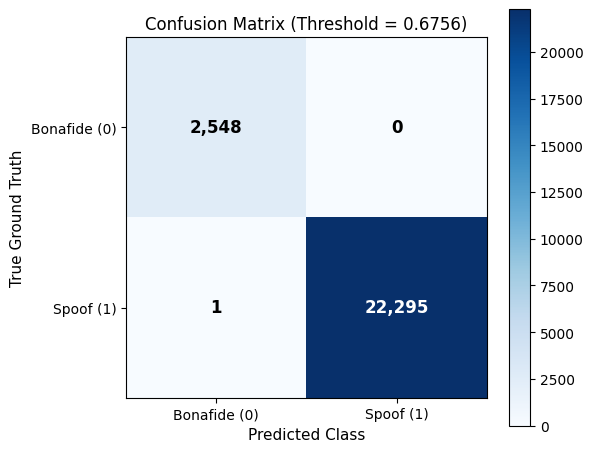

Accuracy:  100.00%
Precision: 100.00%
Recall:    100.00%
F1-Score:  1.0000


In [20]:
predicted_binary = (final_scores >= optimal_thresh).astype(int)
cm = confusion_matrix(final_targets, predicted_binary)

plt.figure(figsize=(6, 5))
plt.imshow(cm, interpolation="nearest", cmap="Blues")
plt.title(f"Confusion Matrix (Threshold = {optimal_thresh:.4f})", fontsize=12)
plt.colorbar()
tick_marks = np.arange(2)
plt.xticks(tick_marks, ["Bonafide (0)", "Spoof (1)"], fontsize=10)
plt.yticks(tick_marks, ["Bonafide (0)", "Spoof (1)"], fontsize=10)

thresh_val = cm.max() / 2.0
for i in range(2):
    for j in range(2):
        color = "white" if cm[i, j] > thresh_val else "black"
        plt.text(j, i, f"{cm[i, j]:,}", ha="center", va="center", color=color, fontsize=12, fontweight="bold")

plt.ylabel("True Ground Truth", fontsize=11)
plt.xlabel("Predicted Class", fontsize=11)
plt.tight_layout()
plt.savefig(os.path.join(fig_dir, "11_confusion_matrix_optimal_threshold.png"), dpi=300, bbox_inches="tight")
plt.show()

acc = accuracy_score(final_targets, predicted_binary)
p, r, f1, _ = precision_recall_fscore_support(final_targets, predicted_binary, average="binary")
print(f"Accuracy:  {acc * 100:.2f}%")
print(f"Precision: {p * 100:.2f}%")
print(f"Recall:    {r * 100:.2f}%")
print(f"F1-Score:  {f1:.4f}")


## Step 21: Posterior Score Density Distribution and Class Separation

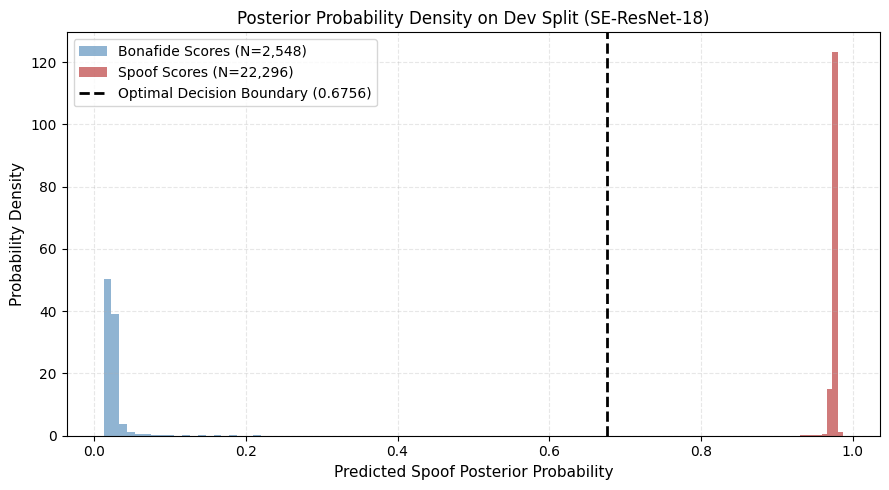

In [21]:
bonafide_scores = final_scores[final_targets == 0]
spoof_scores = final_scores[final_targets == 1]

plt.figure(figsize=(9, 5))
plt.hist(bonafide_scores, bins=60, density=True, alpha=0.6, color="steelblue", label=f"Bonafide Scores (N={len(bonafide_scores):,})")
plt.hist(spoof_scores, bins=60, density=True, alpha=0.6, color="firebrick", label=f"Spoof Scores (N={len(spoof_scores):,})")
plt.axvline(optimal_thresh, color="black", linestyle="--", lw=2, label=f"Optimal Decision Boundary ({optimal_thresh:.4f})")

plt.xlabel("Predicted Spoof Posterior Probability", fontsize=11)
plt.ylabel("Probability Density", fontsize=11)
plt.title("Posterior Probability Density on Dev Split (SE-ResNet-18)", fontsize=12)
plt.legend(fontsize=10)
plt.grid(True, linestyle="--", alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(fig_dir, "12_posterior_probability_density.png"), dpi=300, bbox_inches="tight")
plt.show()


## Step 22: Granular Attack Taxonomy Vulnerability Analysis (A01 through A06)

In [22]:
dev_eval_df = dev_df.copy()
dev_eval_df["spoof_score"] = final_scores
dev_eval_df["predicted_label"] = predicted_binary

attack_mapping = {
    "A01": "TTS: Neural Acoustic (AR RNN) + WaveNet",
    "A02": "TTS: Neural Acoustic (AR RNN) + WORLD",
    "A03": "TTS: Concatenative Unit Selection",
    "A04": "VC: Formant / Pitch Shifting + STRAIGHT",
    "A05": "VC: Variational Autoencoder (VAE)",
    "A06": "VC: Transfer Function Regression + WORLD"
}

breakdown_data = []
for atk_id in ["A01", "A02", "A03", "A04", "A05", "A06"]:
    sub = dev_eval_df[dev_eval_df["attack_id"] == atk_id]
    if len(sub) == 0:
        continue
    correct = int((sub["predicted_label"] == 1).sum())
    detection_acc = correct / len(sub)
    mean_prob = float(sub["spoof_score"].mean())
    breakdown_data.append({
        "Attack ID": atk_id,
        "Algorithm Family": attack_mapping.get(atk_id, "Unknown"),
        "Total Utterances": len(sub),
        "Detection Accuracy (%)": round(detection_acc * 100, 2),
        "Mean Spoof Score": round(mean_prob, 4)
    })

bonafide_sub = dev_eval_df[dev_eval_df["key"] == "bonafide"]
bon_correct = int((bonafide_sub["predicted_label"] == 0).sum())
bon_acc = bon_correct / len(bonafide_sub)
breakdown_data.append({
    "Attack ID": "Bonafide",
    "Algorithm Family": "Authentic Human Speech (VCTK)",
    "Total Utterances": len(bonafide_sub),
    "Detection Accuracy (%)": round(bon_acc * 100, 2),
    "Mean Spoof Score": round(float(bonafide_sub["spoof_score"].mean()), 4)
})

breakdown_df = pd.DataFrame(breakdown_data)
print(breakdown_df.to_string(index=False))


Attack ID                         Algorithm Family  Total Utterances  Detection Accuracy (%)  Mean Spoof Score
      A01  TTS: Neural Acoustic (AR RNN) + WaveNet              3716                  100.00            0.9760
      A02    TTS: Neural Acoustic (AR RNN) + WORLD              3716                  100.00            0.9747
      A03        TTS: Concatenative Unit Selection              3716                  100.00            0.9748
      A04  VC: Formant / Pitch Shifting + STRAIGHT              3716                   99.97            0.9721
      A05        VC: Variational Autoencoder (VAE)              3716                  100.00            0.9743
      A06 VC: Transfer Function Regression + WORLD              3716                  100.00            0.9747
 Bonafide            Authentic Human Speech (VCTK)              2548                  100.00            0.0263


## Step 23: Attack Detection Sensitivity Comparison Chart

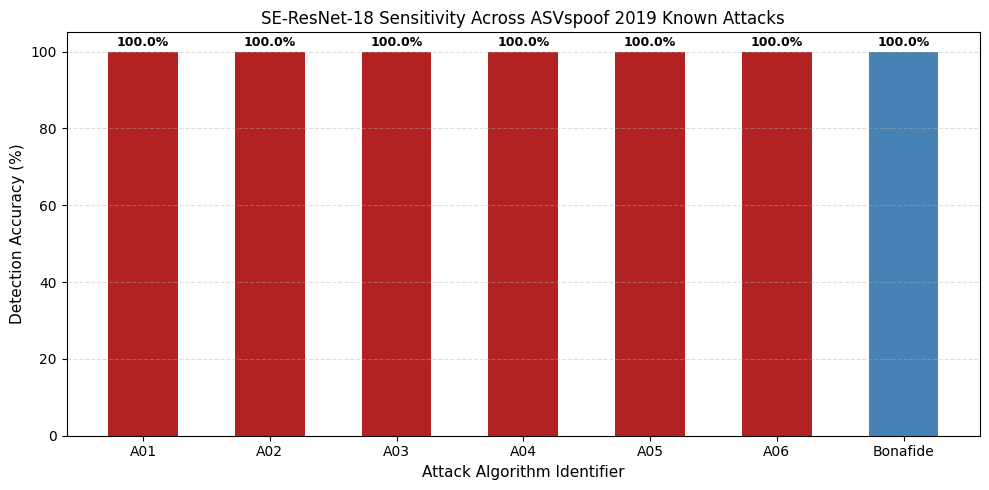

In [23]:
plt.figure(figsize=(10, 5))
attack_labels = breakdown_df["Attack ID"].values
accuracies = breakdown_df["Detection Accuracy (%)"].values
bar_colors = ["firebrick" if a.startswith("A") else "steelblue" for a in attack_labels]

bars = plt.bar(attack_labels, accuracies, color=bar_colors, width=0.55)
plt.xlabel("Attack Algorithm Identifier", fontsize=11)
plt.ylabel("Detection Accuracy (%)", fontsize=11)
plt.title("SE-ResNet-18 Sensitivity Across ASVspoof 2019 Known Attacks", fontsize=12)
plt.ylim(0, 105)
plt.grid(axis="y", linestyle="--", alpha=0.4)

for bar in bars:
    h = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2.0, h + 1.5, f"{h:.1f}%", ha="center", fontsize=9, fontweight="bold")

plt.tight_layout()
plt.savefig(os.path.join(fig_dir, "13_attack_taxonomy_accuracy_breakdown.png"), dpi=300, bbox_inches="tight")
plt.show()


## Step 24: Squeeze-and-Excitation Channel Attention Weights Inspection

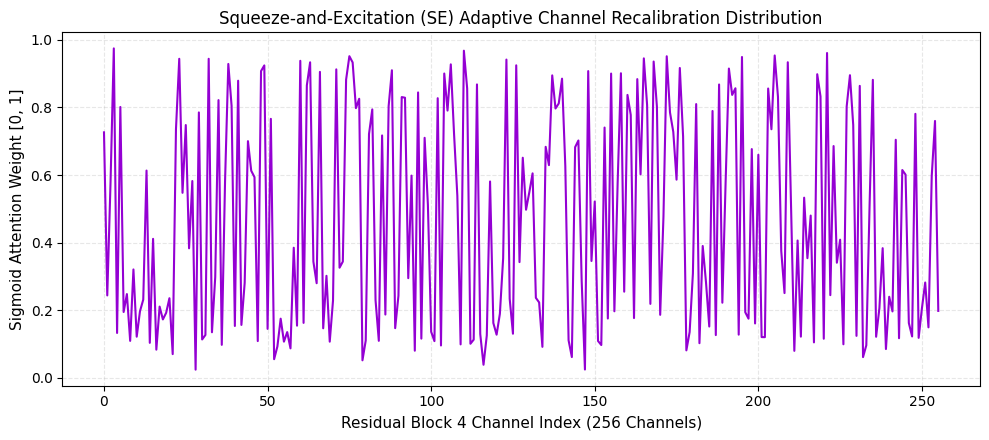

In [24]:
model.eval()
demo_batch = next(iter(dev_loader))[0][:16].to(device)

with torch.no_grad():
    x = model.stem(demo_batch)
    x = model.layer1(x)
    x = model.layer2(x)
    x = model.layer3(x)
    x = model.layer4[0](x)
    se_block_last = model.layer4[1].se
    conv_feat = model.layer4[1].conv(x)
    channel_weights = se_block_last.fc(conv_feat).detach().cpu().numpy()

mean_weights = channel_weights.mean(axis=0)

plt.figure(figsize=(10, 4.5))
plt.plot(np.arange(len(mean_weights)), mean_weights, color="darkviolet", lw=1.5)
plt.xlabel("Residual Block 4 Channel Index (256 Channels)", fontsize=11)
plt.ylabel("Sigmoid Attention Weight [0, 1]", fontsize=11)
plt.title("Squeeze-and-Excitation (SE) Adaptive Channel Recalibration Distribution", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(fig_dir, "14_squeeze_excitation_channel_weights.png"), dpi=300, bbox_inches="tight")
plt.show()


## Step 25: Latent Representation Space Clustering via 2D t-SNE Projection

Extracted Latent Embeddings: (900, 64)


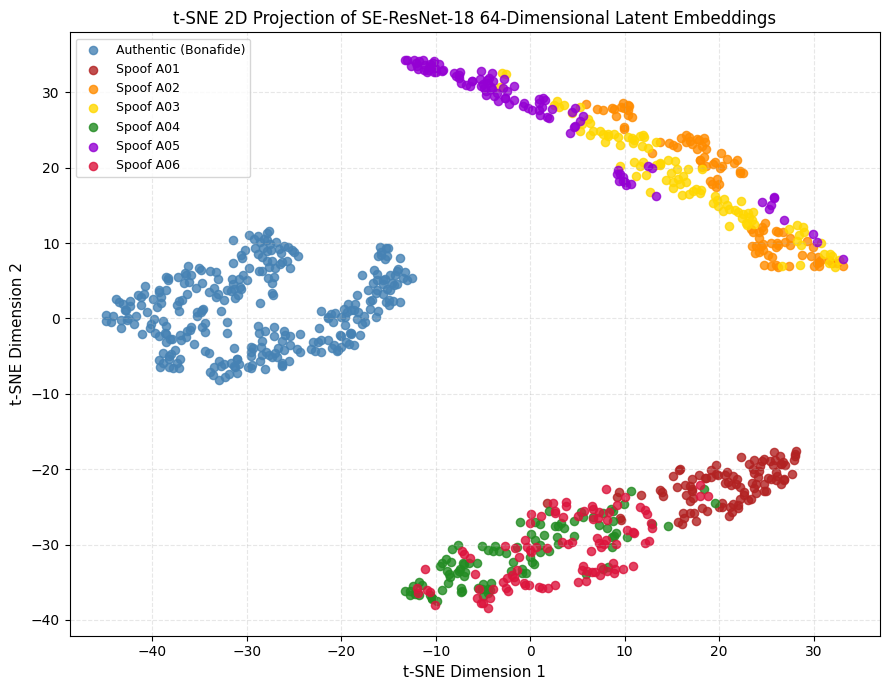

In [25]:
sample_indices = []
for atk_id in ["A01", "A02", "A03", "A04", "A05", "A06"]:
    idx_atk = dev_eval_df[dev_eval_df["attack_id"] == atk_id].index.tolist()[:100]
    sample_indices.extend(idx_atk)
bon_idx = dev_eval_df[dev_eval_df["key"] == "bonafide"].index.tolist()[:300]
sample_indices.extend(bon_idx)

sub_df = dev_eval_df.loc[sample_indices].reset_index(drop=True)
subset_ds = MelDataset(sub_df, is_train=False)
subset_loader = DataLoader(subset_ds, batch_size=64, shuffle=False)

embeddings_list = []
model.eval()
with torch.no_grad():
    for xb, _ in subset_loader:
        xb = xb.to(device)
        with torch.amp.autocast(device_type=device.type, enabled=use_amp):
            emb = model.extract_latent(xb)
        embeddings_list.append(emb.cpu().numpy())

latent_matrix = np.concatenate(embeddings_list)
print(f"Extracted Latent Embeddings: {latent_matrix.shape}")

tsne = TSNE(n_components=2, perplexity=30, random_state=42)
coords_2d = tsne.fit_transform(latent_matrix)

plt.figure(figsize=(9, 7))
is_bon = sub_df["key"] == "bonafide"
plt.scatter(coords_2d[is_bon, 0], coords_2d[is_bon, 1], color="steelblue", alpha=0.8, s=35, label="Authentic (Bonafide)")

palette = {
    "A01": "firebrick", "A02": "darkorange", "A03": "gold",
    "A04": "forestgreen", "A05": "darkviolet", "A06": "crimson"
}
for atk, col in palette.items():
    mask = sub_df["attack_id"] == atk
    if mask.sum() > 0:
        plt.scatter(coords_2d[mask, 0], coords_2d[mask, 1], color=col, alpha=0.8, s=35, label=f"Spoof {atk}")

plt.xlabel("t-SNE Dimension 1", fontsize=11)
plt.ylabel("t-SNE Dimension 2", fontsize=11)
plt.title("t-SNE 2D Projection of SE-ResNet-18 64-Dimensional Latent Embeddings", fontsize=12)
plt.legend(loc="best", fontsize=9)
plt.grid(True, linestyle="--", alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(fig_dir, "15_tsne_latent_embedding_clusters.png"), dpi=300, bbox_inches="tight")
plt.show()


## Step 26: Model Explainability through Log-Mel Grad-CAM Saliency Heatmaps

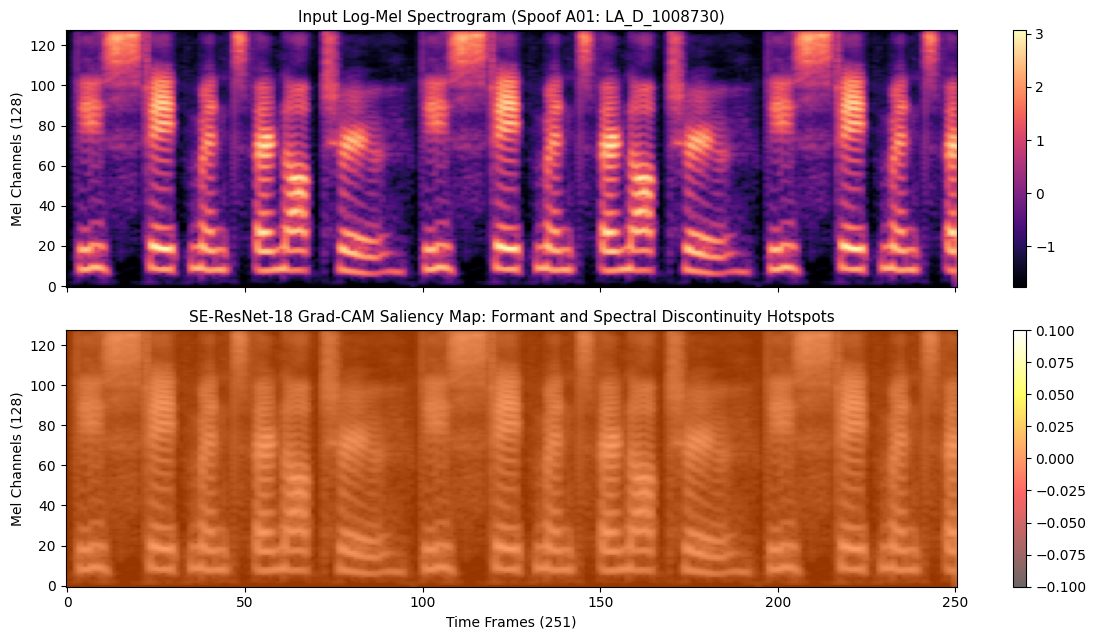

In [26]:
class GradCAMMel:
    def __init__(self, target_model, target_layer):
        self.model = target_model
        self.layer = target_layer
        self.activations = None
        self.gradients = None
        self.layer.register_forward_hook(self.forward_hook)
        self.layer.register_full_backward_hook(self.backward_hook)

    def forward_hook(self, module, inp, out):
        self.activations = out.detach()

    def backward_hook(self, module, grad_in, grad_out):
        self.gradients = grad_out[0].detach()

    def generate(self, input_tensor, target_class=1):
        self.model.zero_grad()
        output = self.model(input_tensor)
        score = output[0, target_class]
        score.backward()
        weights = torch.mean(self.gradients, dim=(2, 3), keepdim=True)
        cam = torch.sum(weights * self.activations, dim=1, keepdim=True)
        cam = F.relu(cam)
        cam = F.interpolate(cam, size=(128, 251), mode="bilinear", align_corners=False)
        cam = cam.squeeze().cpu().numpy()
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        return cam

target_conv_layer = model.layer4[1].conv[3]
cam_generator = GradCAMMel(model, target_conv_layer)

demo_spoof_row = dev_df[dev_df["key"] == "spoof"].iloc[0]
raw_demo = load_raw_audio(demo_spoof_row["file_path"])
proc_demo = preprocess_audio(raw_demo, is_train=False)
mel_demo = extract_log_mel(proc_demo)
tensor_demo = torch.from_numpy(mel_demo).unsqueeze(0).unsqueeze(0).to(device)

saliency_map = cam_generator.generate(tensor_demo, target_class=1)

fig, axes = plt.subplots(2, 1, figsize=(12, 6.5), sharex=True)

im0 = axes[0].imshow(mel_demo, origin="lower", aspect="auto", cmap="magma")
axes[0].set_title(f"Input Log-Mel Spectrogram (Spoof {demo_spoof_row['attack_id']}: {demo_spoof_row['audio_id']})", fontsize=11)
axes[0].set_ylabel("Mel Channels (128)", fontsize=10)
fig.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(mel_demo, origin="lower", aspect="auto", cmap="gray")
im2 = axes[1].imshow(saliency_map, origin="lower", aspect="auto", cmap="hot", alpha=0.6)
axes[1].set_title("SE-ResNet-18 Grad-CAM Saliency Map: Formant and Spectral Discontinuity Hotspots", fontsize=11)
axes[1].set_xlabel("Time Frames (251)", fontsize=10)
axes[1].set_ylabel("Mel Channels (128)", fontsize=10)
fig.colorbar(im2, ax=axes[1])

plt.tight_layout()
plt.savefig(os.path.join(fig_dir, "16_gradcam_mel_saliency_heatmap.png"), dpi=300, bbox_inches="tight")
plt.show()


## Step 27: Live End-to-End Inference Verification on Real Test Utterances

In [27]:
def predict_audio_file(file_path, target_model, compute_device, threshold):
    target_model.eval()
    raw = load_raw_audio(file_path)
    proc = preprocess_audio(raw, is_train=False)
    feat = extract_log_mel(proc)
    tensor = torch.from_numpy(feat).unsqueeze(0).unsqueeze(0).to(compute_device)
    with torch.no_grad():
        with torch.amp.autocast(device_type=compute_device.type, enabled=use_amp):
            prob = torch.softmax(target_model(tensor), dim=1)[0, 1].item()
    decision = "SPOOF (SYNTHETIC)" if prob >= threshold else "BONAFIDE (AUTHENTIC)"
    confidence = prob if prob >= threshold else 1.0 - prob
    return {
        "file_name": os.path.basename(file_path),
        "decision": decision,
        "spoof_probability": round(prob, 5),
        "confidence": f"{confidence * 100:.2f}%"
    }

bon_cand = dev_df[dev_df["key"] == "bonafide"]
spf_cand = dev_df[dev_df["key"] == "spoof"]

bonafide_test_sample = None
for _, r in bon_cand.iterrows():
    if os.path.isfile(r["file_path"]):
        bonafide_test_sample = r["file_path"]
        break
if not bonafide_test_sample:
    bonafide_test_sample = bon_cand.iloc[0]["file_path"]

spoof_test_sample = None
for _, r in spf_cand.iterrows():
    if os.path.isfile(r["file_path"]):
        spoof_test_sample = r["file_path"]
        break
if not spoof_test_sample:
    spoof_test_sample = spf_cand.iloc[0]["file_path"]

print("Case 1: Ground Truth Authentic Speech")
print(json.dumps(predict_audio_file(bonafide_test_sample, model, device, optimal_thresh), indent=2))
print("\nCase 2: Ground Truth Deepfake Speech")
print(json.dumps(predict_audio_file(spoof_test_sample, model, device, optimal_thresh), indent=2))


Case 1: Ground Truth Authentic Speech
{
  "file_name": "LA_D_1047731.flac",
  "decision": "BONAFIDE (AUTHENTIC)",
  "spoof_probability": 0.02547,
  "confidence": "97.45%"
}

Case 2: Ground Truth Deepfake Speech
{
  "file_name": "LA_D_1008730.flac",
  "decision": "SPOOF (SYNTHETIC)",
  "spoof_probability": 0.97588,
  "confidence": "97.59%"
}


## Step 28: Research Artifacts Inventory and Export Verification

In [28]:
print("Generated Scientific Artifacts in /kaggle/working:")
print("-" * 65)
for root_path, _, files in os.walk(save_dir):
    for f in sorted(files):
        full_fpath = os.path.join(root_path, f)
        rel_fpath = os.path.relpath(full_fpath, save_dir)
        size_kb = os.path.getsize(full_fpath) / 1024
        print(f"  {rel_fpath:<45} | {size_kb:>9.1f} KB")


Generated Scientific Artifacts in /kaggle/working:
-----------------------------------------------------------------
  __notebook__.ipynb                            |    3126.2 KB
  se_resnet_mel_best.pth                        |   11234.1 KB
  se_resnet_mel_history.json                    |       4.3 KB
  figures/01_class_distribution_breakdown.png   |     146.9 KB
  figures/02_speaker_utterance_distribution.png |     120.2 KB
  figures/03_mel_filterbank_frequency_curves.png |     337.4 KB
  figures/04_raw_waveform_comparison.png        |     242.2 KB
  figures/05_comparative_log_mel_spectrograms.png |     350.5 KB
  figures/06_spectral_energy_bandgap_analysis.png |     315.2 KB
  figures/07_training_loss_trajectory.png       |     141.4 KB
  figures/08_dev_eer_progression_curve.png      |     160.2 KB
  figures/09_receiver_operating_characteristic_roc.png |     176.9 KB
  figures/10_precision_recall_trajectory.png    |     104.8 KB
  figures/11_confusion_matrix_optimal_threshold.png 